** Data Preprocessing**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**REading the stored dataset with outlier controlled**

In [2]:
data = pd.read_csv("/content/drive/MyDrive/Final Eco/cleaned_Cover_Type_data.csv")
data.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,Aspen,1,29
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,Aspen,1,29
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,Lodgepole Pine,1,12
3,2785.0,155.0,18.0,242.0,117.0,3090.0,238.0,238.0,122.0,6211.0,Lodgepole Pine,1,30
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,Aspen,1,29


In [ ]:
data_feature = data
data_feature.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,Aspen,1,29
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,Aspen,1,29
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,Lodgepole Pine,1,12
3,2785.0,155.0,18.0,242.0,117.0,3090.0,238.0,238.0,122.0,6211.0,Lodgepole Pine,1,30
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,Aspen,1,29


In [ ]:
data_feature.select_dtypes(exclude=['object']).columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area', 'Soil_Type'],
      dtype='object')

**Checking the skew value of all the features**

In [ ]:
data_col =['Elevation', 'Aspect', 'Slope',
       'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
       'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon',
       'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points',
       ]

skewness = data[data_col].skew()
skewness

,0
Elevation,-0.340370
Aspect,0.689432
Slope,0.621361
Horizontal_Distance_To_Hydrology,0.792349
Vertical_Distance_To_Hydrology,0.861265
Horizontal_Distance_To_Roadways,-0.058240
Hillshade_9am,-0.740409
Hillshade_Noon,-0.505363
Hillshade_3pm,-0.001189
Horizontal_Distance_To_Fire_Points,0.365249


**Below transformation in this postioin not use**

In [ ]:
from feature_engine.transformation import YeoJohnsonTransformer

# Transform specific columns
yjt = YeoJohnsonTransformer(variables=['Elevation', 'Aspect', 'Slope',
       'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
       'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon',
       'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points',
       ])
df_transformed_new = yjt.fit_transform(data_feature)
df_transformed_new

ModuleNotFoundError: No module named 'feature_engine'

Creating new features in df_tansformed

In [ ]:
#1.Euclidean Distance To Hydrology feature
data_feature['Euclidean_Distance_To_Hydrology'] = np.sqrt(data_feature['Horizontal_Distance_To_Hydrology']**2 + data_feature['Vertical_Distance_To_Hydrology']**2)
#2.Hiullshade_Avg Feature
data_feature['Hillshade_Avg'] = (data_feature['Hillshade_9am'] + data_feature['Hillshade_Noon'] + data_feature['Hillshade_3pm']) / 3

#3.Creating the catagorical feature according to the aspect directions
def categorize_aspect(aspect):
    if (aspect >= 0 and aspect < 45) or (aspect >= 315 and aspect <= 360):
        return 'North'
    elif aspect >= 45 and aspect < 135:
        return 'East'
    elif aspect >= 135 and aspect < 225:
        return 'South'
    elif aspect >= 225 and aspect < 315:
        return 'West'
    else:
        return 'Unknown'

data_feature['Aspect_Category'] = data_feature['Aspect'].apply(categorize_aspect)

#4. Hydro_fire_interaction feature
data_feature["Hydro_fire_interaction"] = abs(data_feature["Horizontal_Distance_To_Hydrology"] -data_feature["Horizontal_Distance_To_Fire_Points"])
#5.Slope _elevation_interaction feature
data_feature["Slop_elevation_interaction"] = (data_feature["Slope"] *data_feature["Elevation"])



In [ ]:
data.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,Aspen,1,29
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,Aspen,1,29
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,Lodgepole Pine,1,12
3,2785.0,155.0,18.0,242.0,117.0,3090.0,238.0,238.0,122.0,6211.0,Lodgepole Pine,1,30
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,Aspen,1,29


In [ ]:
data.shape

(145890, 18)

In [ ]:
data.to_csv("/content/drive/MyDrive/Final Eco/feature_added.csv",index= False)

**once again checking the skew with newely added features**

In [ ]:
data_feature.select_dtypes(exclude=["object"]).columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area', 'Soil_Type',
       'Euclidean_Distance_To_Hydrology', 'Hillshade_Avg',
       'Hydro_fire_interaction', 'Slop_elevation_interaction'],
      dtype='object')

In [ ]:
data_col= ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points',
       'Euclidean_Distance_To_Hydrology', 'Hillshade_Avg',
       'Hydro_fire_interaction', 'Slop_elevation_interaction']
skewness_new = data_feature[data_col].skew()
skewness_new

,0
Elevation,-0.340370
Aspect,0.689432
Slope,0.621361
Horizontal_Distance_To_Hydrology,0.792349
Vertical_Distance_To_Hydrology,0.861265
Horizontal_Distance_To_Roadways,-0.058240
Hillshade_9am,-0.740409
Hillshade_Noon,-0.505363
Hillshade_3pm,-0.001189
Horizontal_Distance_To_Fire_Points,0.365249


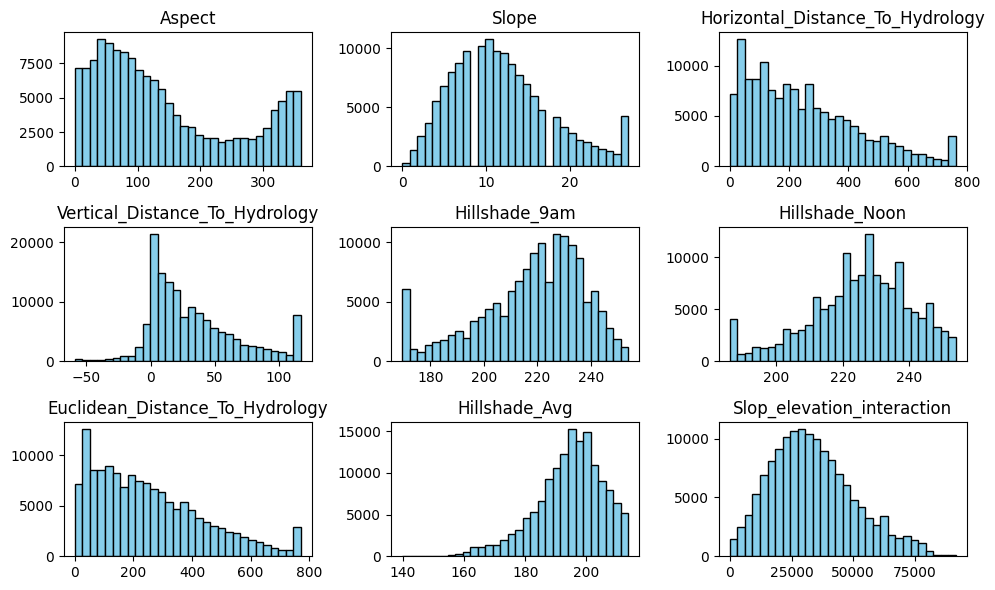

In [ ]:
skewness_data= skewness_new[abs(skewness_new)>0.5].index

plt.figure(figsize=(10,6))

for i, col in enumerate(skewness_data):
  plt.subplot(3,3, i + 1)
  plt.hist(data[col], bins =30, color ="skyblue", edgecolor="black")
  plt.title(f"{col}")
plt.tight_layout()
plt.show()

**Scaling the numerical columns**

In [ ]:
pip install feature_engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 5.3 MB/s eta 0:00:00


In [ ]:
from feature_engine.transformation import YeoJohnsonTransformer
import matplotlib.pyplot as plt

Skewness after Yeo-Johnson Transformation:
Aspect                               -0.099594
Slope                                -0.020527
Horizontal_Distance_To_Hydrology     -0.169816
Vertical_Distance_To_Hydrology        0.087352
Hillshade_9am                        -0.097810
Hillshade_Noon                       -0.040928
Horizontal_Distance_To_Fire_Points   -0.116019
Euclidean_Distance_To_Hydrology      -0.174281
Hillshade_Avg                        -0.050254
Hydro_fire_interaction               -0.145056
Slop_elevation_interaction           -0.042835
dtype: float64


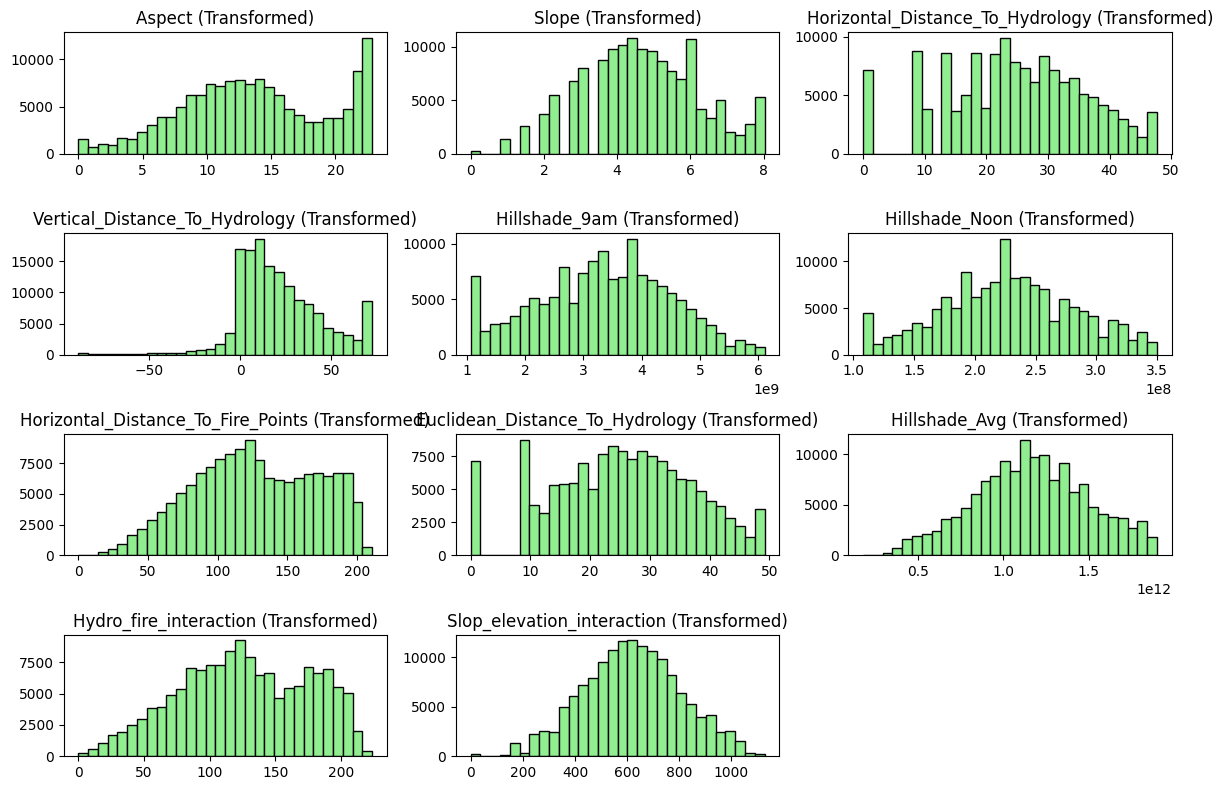

In [ ]:
datas_skewness = skewness_new[abs(skewness_new)>0.35]
yj_transformer = YeoJohnsonTransformer(variables=datas_skewness.index.tolist())
data_transformed = yj_transformer.fit_transform(data_feature[datas_skewness.index.tolist()])

# Replace original skewed columns with transformed ones in the main DataFrame
for col in datas_skewness.index:
    data_feature[col] = data_transformed[col]

# Recheck skewness after transformation
skewness_after_yj = data_feature[datas_skewness.index].skew()
print("Skewness after Yeo-Johnson Transformation:")
print(skewness_after_yj)

# Visualize the distributions after transformation for the highly skewed features
plt.figure(figsize=(12, 8))
for i, col in enumerate(datas_skewness.index):
    plt.subplot(4, 3, i + 1)
    plt.hist(data_feature[col], bins=30, color='lightgreen', edgecolor='black')
    plt.title(f'{col} (Transformed)')
plt.tight_layout()
plt.show()

**Balancing is going to do after skew correction**

In [ ]:
from imblearn.over_sampling import SMOTE, SMOTENC

# Define features (X) and target (y)
X = data_feature.drop('Cover_Type', axis=1)
y = data_feature["Cover_Type"]

categorical_cols = ['Aspect_Category', 'Wilderness_Area', "Soil_Type"]

# SMOTE needs categorical columns as indices for non-continuous features
categorical_indices = [X.columns.get_loc(col) for col in categorical_cols]

# Apply SMOTE
smote = SMOTENC(categorical_features=categorical_indices, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Convert to DataFrame
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['Cover_Type'] = y_resampled

# Verify the new class distribution
df_resampled['Cover_Type'].value_counts()

,count
Cover_Type,
Aspen,103071
Lodgepole Pine,103071
Spruce/Fir,103071
Krummholz,103071
Ponderosa Pine,103071
Douglas-fir,103071
Cottonwood/Willow,103071


In [ ]:
df_resampled.shape

(721497, 18)

In [ ]:
df_resampled.to_csv("/content/drive/MyDrive/Final Eco/Over_sampled.csv",index= False)

In [ ]:
df_resampled.select_dtypes(exclude=["object"]).columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area', 'Soil_Type',
       'Euclidean_Distance_To_Hydrology', 'Hillshade_Avg',
       'Hydro_fire_interaction', 'Slop_elevation_interaction'],
      dtype='object')

In [ ]:
da_col =['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points',
       'Euclidean_Distance_To_Hydrology', 'Hillshade_Avg',
       'Hydro_fire_interaction', 'Slop_elevation_interaction']
skew1 = df_resampled[da_col].skew()
skew1

,0
Elevation,0.415612
Aspect,-0.145160
Slope,-0.282276
Horizontal_Distance_To_Hydrology,-0.042945
Vertical_Distance_To_Hydrology,0.067444
Horizontal_Distance_To_Roadways,0.875965
Hillshade_9am,0.082202
Hillshade_Noon,0.087988
Hillshade_3pm,-0.041724
Horizontal_Distance_To_Fire_Points,0.706402


In [ ]:
df_resampled.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Euclidean_Distance_To_Hydrology,Hillshade_Avg,Aspect_Category,Hydro_fire_interaction,Slop_elevation_interaction,Cover_Type
0,2596.0,9.393286,1.950991,27.619517,0.000000,510.0,3.350964e+09,2.485719e+08,148.0,196.198379,1,29,28.176380,1.326532e+12,East,203.191956,278.572121,Aspen
1,2590.0,9.828599,1.436176,24.972082,-7.070033,390.0,3.286080e+09,2.609240e+08,151.0,195.289176,1,29,25.458961,1.389050e+12,East,203.044531,220.861144,Aspen
2,2804.0,15.021518,4.139057,28.161623,43.188824,3180.0,4.287525e+09,2.737222e+08,135.0,193.527673,1,12,29.160299,1.401839e+12,South,200.076891,543.137718,Lodgepole Pine
3,2785.0,15.778479,6.337154,26.728868,72.458266,3090.0,4.612667e+09,2.737222e+08,122.0,195.052856,1,30,28.778346,1.290144e+12,South,202.232080,801.444352,Lodgepole Pine
4,2595.0,8.835699,1.436176,21.090577,-1.050831,391.0,3.286080e+09,2.567576e+08,150.0,194.393220,1,29,21.467310,1.363759e+12,East,203.155108,221.103970,Aspen


**Scaling the numerical features**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
df_resampled.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area', 'Soil_Type',
       'Euclidean_Distance_To_Hydrology', 'Hillshade_Avg', 'Aspect_Category',
       'Hydro_fire_interaction', 'Slop_elevation_interaction', 'Cover_Type'],
      dtype='object')

In [ ]:
scaler = MinMaxScaler()

numerical_cols = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points',
       'Euclidean_Distance_To_Hydrology', 'Hillshade_Avg',
       'Hydro_fire_interaction', 'Slop_elevation_interaction']

df_resampled[numerical_cols] = scaler.fit_transform(df_resampled[numerical_cols])
df_resampled.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Euclidean_Distance_To_Hydrology,Hillshade_Avg,Aspect_Category,Hydro_fire_interaction,Slop_elevation_interaction,Cover_Type
0,0.228113,0.410781,0.243185,0.579234,0.550705,0.071659,0.453011,0.581044,0.552632,0.930941,1,29,0.573050,0.667351,East,0.908889,0.247178,Aspen
1,0.222276,0.429818,0.179015,0.523712,0.506866,0.054798,0.440134,0.632096,0.572368,0.926627,1,29,0.517783,0.703746,East,0.908230,0.195971,Aspen
2,0.430447,0.656911,0.515921,0.590603,0.818508,0.446817,0.638885,0.684992,0.467105,0.918268,1,12,0.593061,0.711191,South,0.894955,0.481929,Lodgepole Pine
3,0.411965,0.690014,0.789906,0.560555,1.000000,0.434172,0.703415,0.684992,0.381579,0.925505,1,30,0.585293,0.646168,South,0.904596,0.711125,Lodgepole Pine
4,0.227140,0.386397,0.179015,0.442310,0.544189,0.054939,0.440134,0.614876,0.565789,0.922375,1,29,0.436601,0.689023,East,0.908725,0.196187,Aspen


**one hot encoding ofr the catagorical columns**

In [ ]:
from sklearn.preprocessing import OneHotEncoder

cat_col= ['Soil_Type', 'Wilderness_Area','Aspect_Category']

# Initialize OneHotEncoder
ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

encoded_data = ohe.fit_transform(df_resampled[cat_col])
encoded_data=encoded_data.astype(int)

encoded_df = pd.DataFrame(encoded_data, columns=ohe.get_feature_names_out(cat_col))


datas_encoded = pd.concat([df_resampled.drop(columns=cat_col), encoded_df], axis=1)

datas_encoded.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40,Wilderness_Area_2,Wilderness_Area_3,Wilderness_Area_4,Aspect_Category_North,Aspect_Category_South,Aspect_Category_West
0,0.228113,0.410781,0.243185,0.579234,0.550705,0.071659,0.453011,0.581044,0.552632,0.930941,...,0,0,0,0,0,0,0,0,0,0
1,0.222276,0.429818,0.179015,0.523712,0.506866,0.054798,0.440134,0.632096,0.572368,0.926627,...,0,0,0,0,0,0,0,0,0,0
2,0.430447,0.656911,0.515921,0.590603,0.818508,0.446817,0.638885,0.684992,0.467105,0.918268,...,0,0,0,0,0,0,0,0,1,0
3,0.411965,0.690014,0.789906,0.560555,1.000000,0.434172,0.703415,0.684992,0.381579,0.925505,...,0,0,0,0,0,0,0,0,1,0
4,0.227140,0.386397,0.179015,0.442310,0.544189,0.054939,0.440134,0.614876,0.565789,0.922375,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
datas_encoded.shape

(721497, 59)

In [ ]:
datas_encoded.to_csv("/content/drive/MyDrive/Final Eco/input_features_scaled&encoded.csv")

**Feature Importance Checking**

In [ ]:
datas_encoded.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Euclidean_Distance_To_Hydrology',
       'Hillshade_Avg', 'Hydro_fire_interaction', 'Slop_elevation_interaction',
       'Cover_Type', 'Soil_Type_2', 'Soil_Type_3', 'Soil_Type_4',
       'Soil_Type_5', 'Soil_Type_6', 'Soil_Type_7', 'Soil_Type_8',
       'Soil_Type_9', 'Soil_Type_10', 'Soil_Type_11', 'Soil_Type_12',
       'Soil_Type_13', 'Soil_Type_14', 'Soil_Type_16', 'Soil_Type_17',
       'Soil_Type_18', 'Soil_Type_19', 'Soil_Type_20', 'Soil_Type_21',
       'Soil_Type_22', 'Soil_Type_23', 'Soil_Type_24', 'Soil_Type_25',
       'Soil_Type_26', 'Soil_Type_27', 'Soil_Type_28', 'Soil_Type_29',
       'Soil_Type_30', 'Soil_Type_31', 'Soil_Type_32', 'Soil_Type_33',
       'Soil_Type_34', 'Soil_Type_35', 'Soil_Type_36', 'Soil_Type_37',
 

In [ ]:
from sklearn.ensemble import RandomForestClassifier


# Define X (features) by dropping the original 'Cover_Type' and its one-hot encoded versions
X = datas_encoded.drop(columns=["Cover_Type"])

# Define y (target) using the original 'Cover_Type' column
y = datas_encoded["Cover_Type"]

# Train a Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sort by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display the top features
feature_importance_df

,Feature,Importance
0,Elevation,2.168867e-01
5,Horizontal_Distance_To_Roadways,8.603919e-02
9,Horizontal_Distance_To_Fire_Points,5.705017e-02
54,Wilderness_Area_4,4.723428e-02
12,Hydro_fire_interaction,4.666894e-02
53,Wilderness_Area_3,4.348827e-02
22,Soil_Type_10,3.701091e-02
3,Horizontal_Distance_To_Hydrology,3.668513e-02
10,Euclidean_Distance_To_Hydrology,3.153255e-02
15,Soil_Type_3,2.975734e-02


In [ ]:
pd.set_option('display.float_format', '{:.6f}'.format)
feature_importance_df.head(20)

,Feature,Importance
0,Elevation,0.216887
5,Horizontal_Distance_To_Roadways,0.086039
9,Horizontal_Distance_To_Fire_Points,0.057050
54,Wilderness_Area_4,0.047234
12,Hydro_fire_interaction,0.046669
53,Wilderness_Area_3,0.043488
22,Soil_Type_10,0.037011
3,Horizontal_Distance_To_Hydrology,0.036685
10,Euclidean_Distance_To_Hydrology,0.031533
15,Soil_Type_3,0.029757


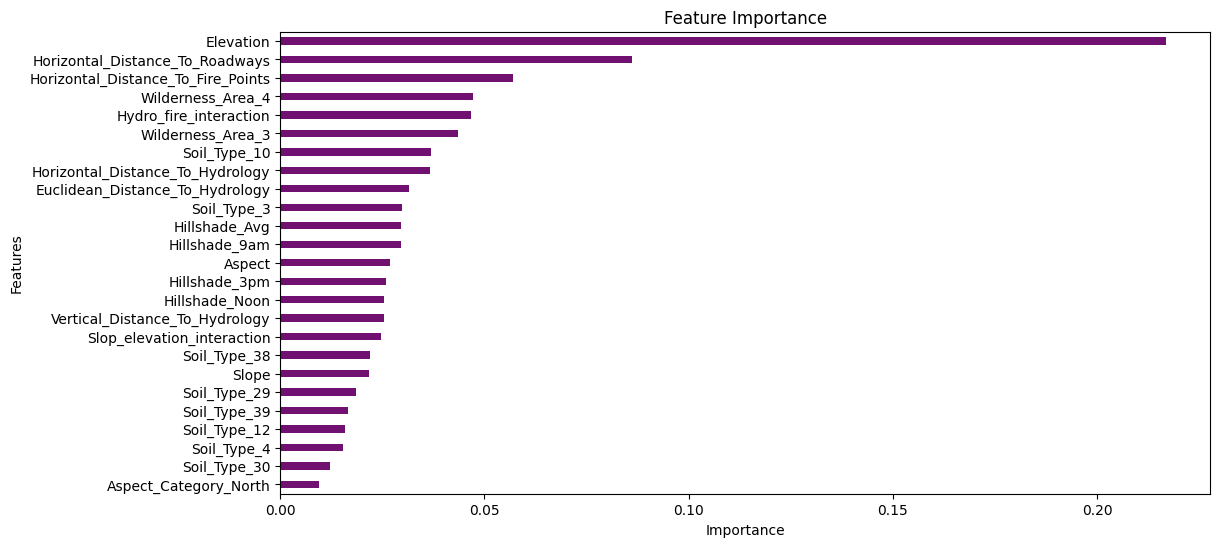

In [ ]:
import seaborn as sns
plt.figure(figsize=(12,6))
sns.barplot(data=feature_importance_df.head(25), x="Importance", y="Feature", color="purple", width =0.4 )
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [ ]:
# columns to consider

data_col1=feature_importance_df['Feature'][:20].tolist()
data_col1

['Elevation',
 'Horizontal_Distance_To_Roadways',
 'Horizontal_Distance_To_Fire_Points',
 'Wilderness_Area_4',
 'Hydro_fire_interaction',
 'Wilderness_Area_3',
 'Soil_Type_10',
 'Horizontal_Distance_To_Hydrology',
 'Euclidean_Distance_To_Hydrology',
 'Soil_Type_3',
 'Hillshade_Avg',
 'Hillshade_9am',
 'Aspect',
 'Hillshade_3pm',
 'Hillshade_Noon',
 'Vertical_Distance_To_Hydrology',
 'Slop_elevation_interaction',
 'Soil_Type_38',
 'Slope',
 'Soil_Type_29']

In [ ]:
data_feature = ['Elevation','Horizontal_Distance_To_Roadways','Horizontal_Distance_To_Fire_Points','Wilderness_Area_4',
 'Hydro_fire_interaction','Wilderness_Area_3','Soil_Type_10','Horizontal_Distance_To_Hydrology','Euclidean_Distance_To_Hydrology',
 'Soil_Type_3','Hillshade_Avg','Hillshade_9am','Aspect','Hillshade_3pm','Hillshade_Noon','Vertical_Distance_To_Hydrology','Slop_elevation_interaction','Soil_Type_38',
 'Slope',
 'Soil_Type_29']

**Making the data frame with importance feature**

In [ ]:
importance_feature =datas_encoded[data_feature]
importance_feature = pd.concat([importance_feature, datas_encoded["Cover_Type"]], axis=1)
importance_feature.head()
importance_feature.shape

(721497, 21)

**Storing the importance features**

In [ ]:
importance_feature.to_csv("/content/drive/MyDrive/Final Eco/importance_feature.csv", index=False)

**Label encoding the output variables**

In [ ]:
from sklearn.preprocessing import LabelEncoder
le =LabelEncoder()
importance_feature["Cover_Type"]=le.fit_transform(importance_feature["Cover_Type"])
importance_feature.head()

,Elevation,Horizontal_Distance_To_Roadways,Horizontal_Distance_To_Fire_Points,Wilderness_Area_4,Hydro_fire_interaction,Wilderness_Area_3,Soil_Type_10,Horizontal_Distance_To_Hydrology,Euclidean_Distance_To_Hydrology,Soil_Type_3,...,Hillshade_9am,Aspect,Hillshade_3pm,Hillshade_Noon,Vertical_Distance_To_Hydrology,Slop_elevation_interaction,Soil_Type_38,Slope,Soil_Type_29,Cover_Type
0,0.228113,0.071659,0.930941,0,0.908889,0,0,0.579234,0.573050,0,...,0.453011,0.410781,0.552632,0.581044,0.550705,0.247178,0,0.243185,1,0
1,0.222276,0.054798,0.926627,0,0.908230,0,0,0.523712,0.517783,0,...,0.440134,0.429818,0.572368,0.632096,0.506866,0.195971,0,0.179015,1,0
2,0.430447,0.446817,0.918268,0,0.894955,0,0,0.590603,0.593061,0,...,0.638885,0.656911,0.467105,0.684992,0.818508,0.481929,0,0.515921,0,4
3,0.411965,0.434172,0.925505,0,0.904596,0,0,0.560555,0.585293,0,...,0.703415,0.690014,0.381579,0.684992,1.000000,0.711125,0,0.789906,0,4
4,0.227140,0.054939,0.922375,0,0.908725,0,0,0.442310,0.436601,0,...,0.440134,0.386397,0.565789,0.614876,0.544189,0.196187,0,0.179015,1,0


In [ ]:
importance_feature.to_csv("/content/drive/MyDrive/Final Eco/target_enoded.csv",index=False)

**Storing the label encoder object as a picklefile**

In [ ]:
import pickle

with open("/content/drive/MyDrive/Final Eco/lable_encoder.pkl", 'wb') as f:
    pickle.dump(le,f)

**EDA Aanalysis**

In [3]:
eda = pd.read_csv("/content/drive/MyDrive/Final Eco/feature_added.csv")
eda.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type,Euclidean_Distance_To_Hydrology,Hillshade_Avg,Aspect_Category,Hydro_fire_interaction,Slop_elevation_interaction
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,Aspen,1,29,258.000000,200.333333,East,6021.0,7788.0
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,Aspen,1,29,212.084889,202.000000,East,6013.0,5180.0
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,Lodgepole Pine,1,12,275.769832,202.333333,South,5853.0,25236.0
3,2785.0,155.0,18.0,242.0,117.0,3090.0,238.0,238.0,122.0,6211.0,Lodgepole Pine,1,30,268.799182,199.333333,South,5969.0,50130.0
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,Aspen,1,29,153.003268,201.333333,East,6019.0,5190.0


#1. 2-D Scatter plot with color-coding for each class.
# Here 'sns' corresponds to seaborn.

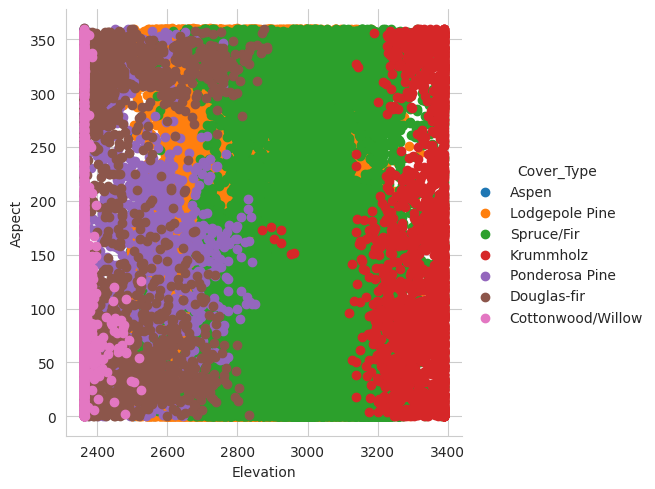

In [5]:
sns.set_style("whitegrid");
sns.FacetGrid(eda, hue="Cover_Type", height =5).map(plt.scatter, "Elevation", "Aspect").add_legend();
plt.show();

**2. Scoter plot for the Aspen**

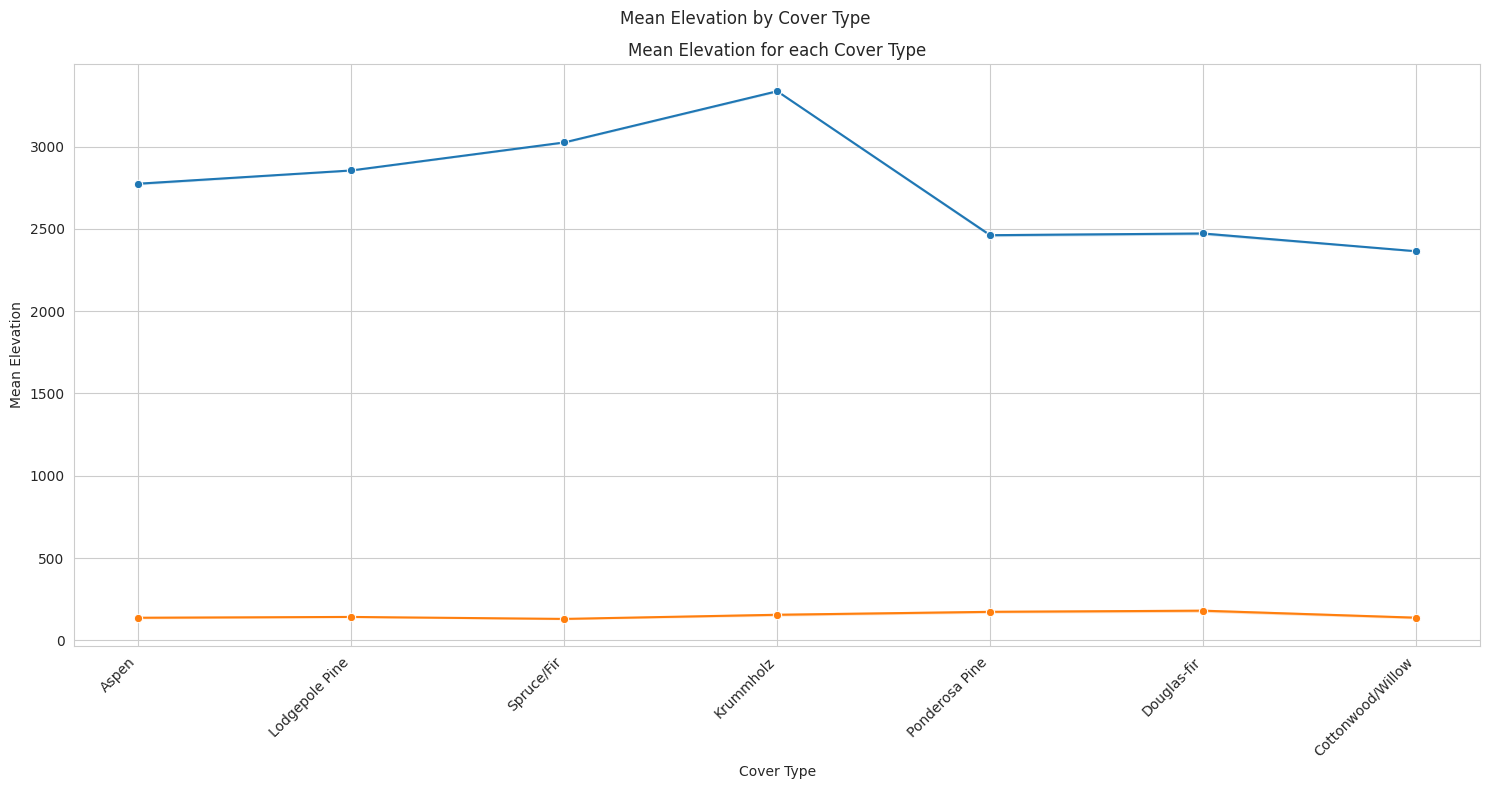

In [6]:
plt.figure(figsize=(15,8))
plt.suptitle("Mean Elevation by Cover Type")
sns.lineplot(data=data, x="Cover_Type", y="Elevation", marker='o')
sns.lineplot(data=data, x="Cover_Type", y="Aspect", marker='o')
plt.title("Mean Elevation for each Cover Type")
plt.xlabel("Cover Type")
plt.ylabel("Mean Elevation")
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

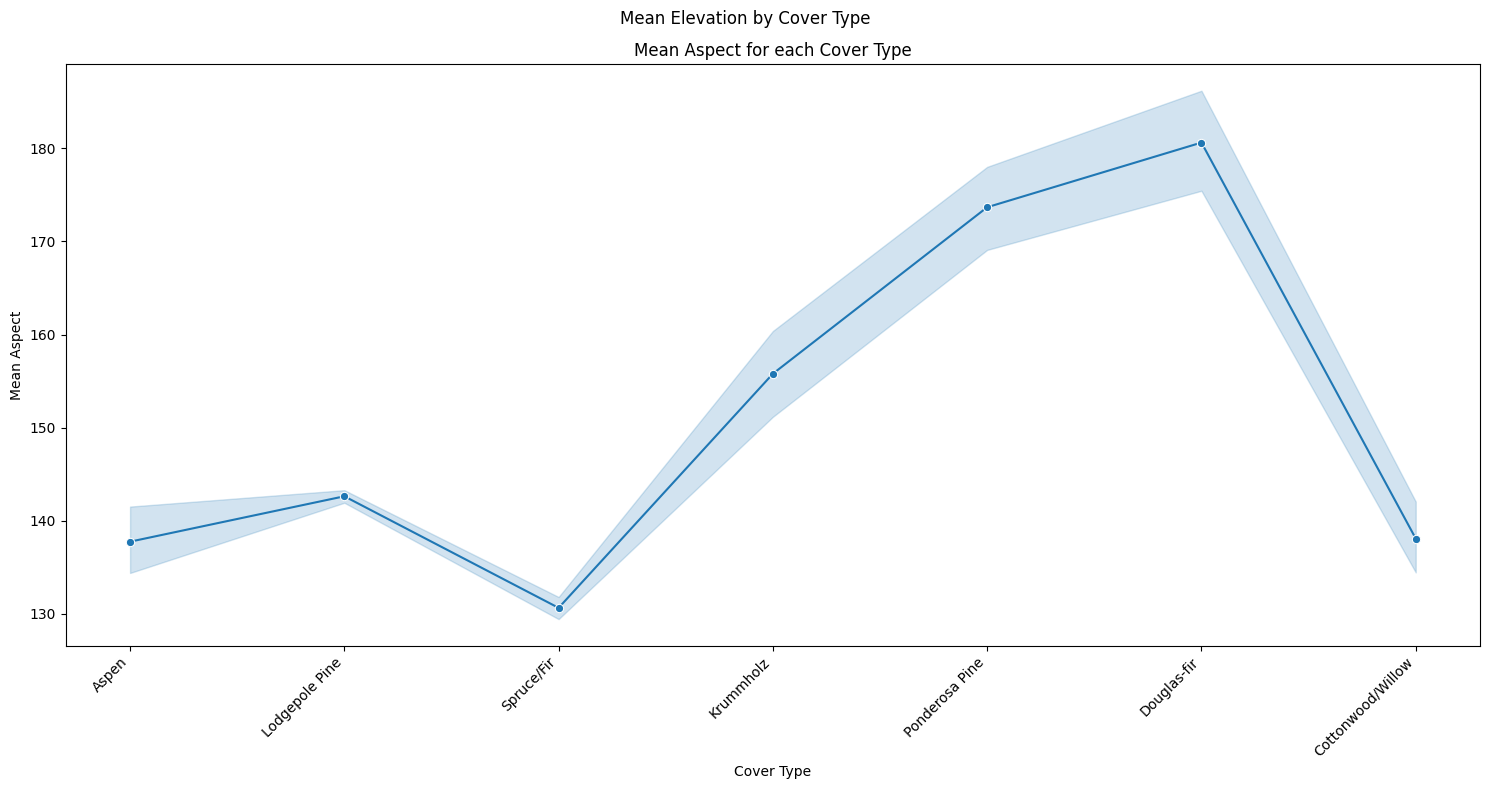

In [ ]:
plt.figure(figsize=(15,8))
plt.suptitle("Mean Elevation by Cover Type")
sns.lineplot(data=data, x="Cover_Type", y="Aspect", marker='o')
plt.title("Mean Aspect for each Cover Type")
plt.xlabel("Cover Type")
plt.ylabel("Mean Aspect")
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

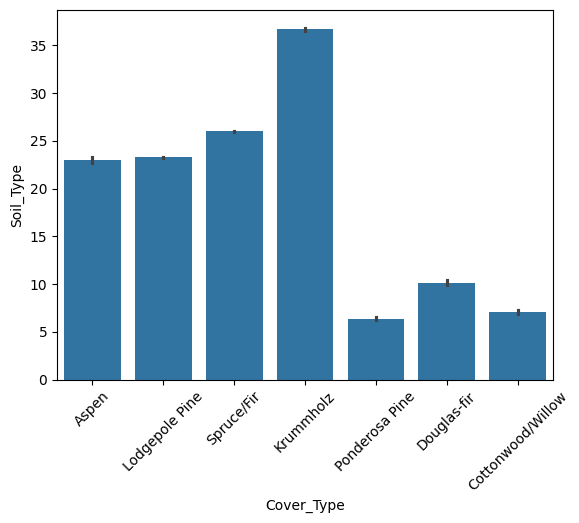

In [ ]:
sns.barplot(data= data_feature, x="Cover_Type", y="Soil_Type" )
plt.xticks(rotation=45)
plt.show()

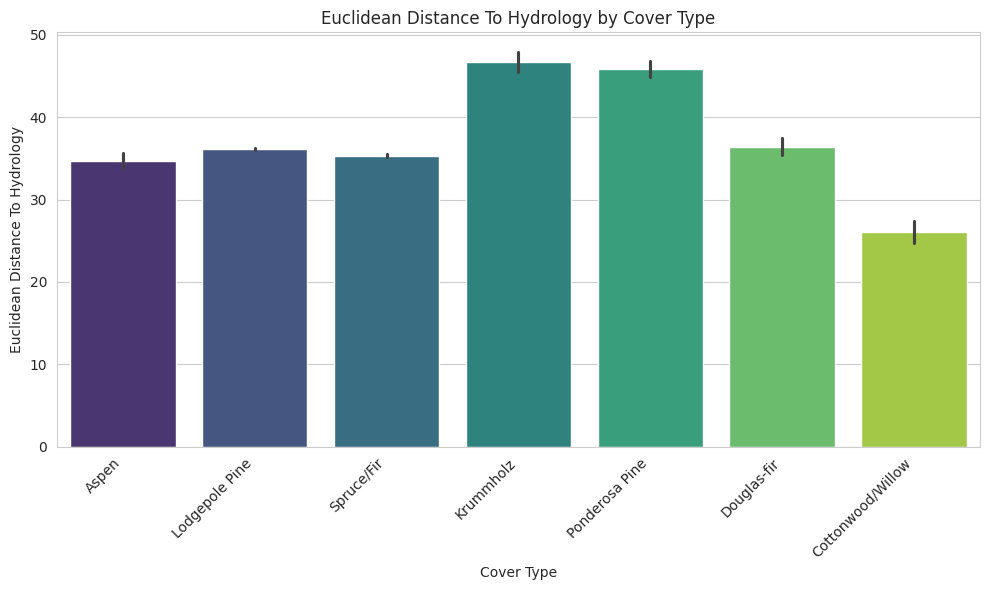

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_transformed_new, x="Cover_Type", y="Euclidean_Distance_To_Hydrology", hue="Cover_Type", palette="viridis", legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Euclidean Distance To Hydrology by Cover Type')
plt.xlabel('Cover Type')
plt.ylabel('Euclidean Distance To Hydrology')
plt.tight_layout()
plt.show()

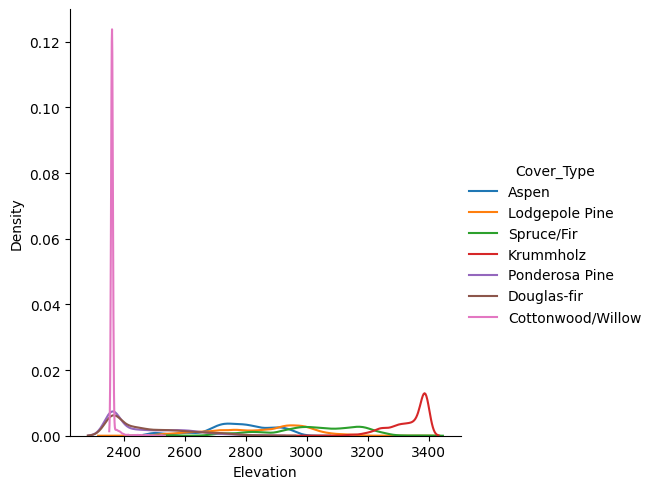

In [ ]:
sns.FacetGrid(data_feature, hue="Cover_Type", height=5).map(sns.kdeplot, "Elevation").add_legend();
plt.show();


### Line Plots for Hillshade Features vs. Cover Type

These plots show the average values of Hillshade at 9am, Noon, and 3pm for each `Cover_Type`. This can reveal how sun exposure at different times of the day varies across different forest types.

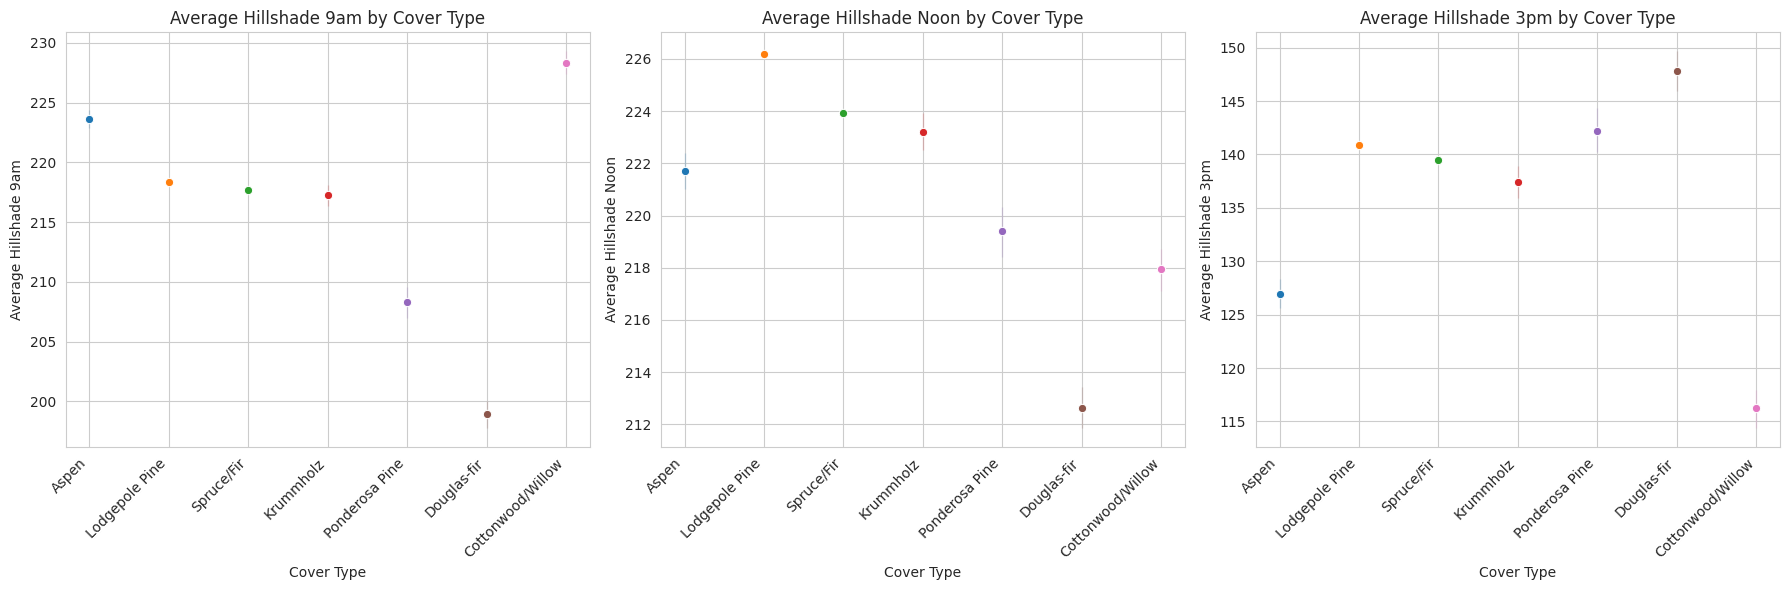

In [16]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.lineplot(data=eda, x='Cover_Type', y='Hillshade_9am', marker='o', hue='Cover_Type', legend=False)
plt.title('Average Hillshade 9am by Cover Type')
plt.xlabel('Cover Type')
plt.ylabel('Average Hillshade 9am')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 3, 2)
sns.lineplot(data=eda, x='Cover_Type', y='Hillshade_Noon', marker='o', hue='Cover_Type', legend=False)
plt.title('Average Hillshade Noon by Cover Type')
plt.xlabel('Cover Type')
plt.ylabel('Average Hillshade Noon')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 3, 3)
sns.lineplot(data=eda, x='Cover_Type', y='Hillshade_3pm', marker='o', hue='Cover_Type', legend=False)
plt.title('Average Hillshade 3pm by Cover Type')
plt.xlabel('Cover Type')
plt.ylabel('Average Hillshade 3pm')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Box Plot for Elevation vs. Cover Type

This box plot visualizes the distribution of 'Elevation' for each `Cover_Type`, showing the median, interquartile range, and potential outliers. This helps to understand if certain forest types tend to grow at specific elevations.

### Line Plot for Horizontal Distance To Hydrology vs. Cover Type

This plot shows the average 'Horizontal_Distance_To_Hydrology' for each `Cover_Type`, which can indicate how proximity to water sources varies across different forest types.

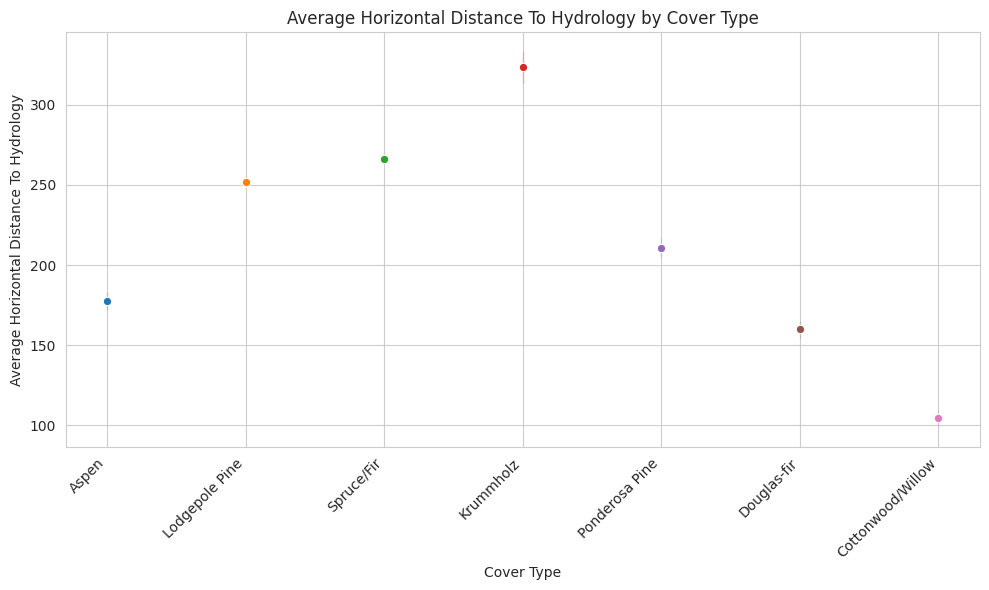

In [18]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=eda, x='Cover_Type', y='Horizontal_Distance_To_Hydrology', marker='o', hue='Cover_Type', legend=False)
plt.title('Average Horizontal Distance To Hydrology by Cover Type')
plt.xlabel('Cover Type')
plt.ylabel('Average Horizontal Distance To Hydrology')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

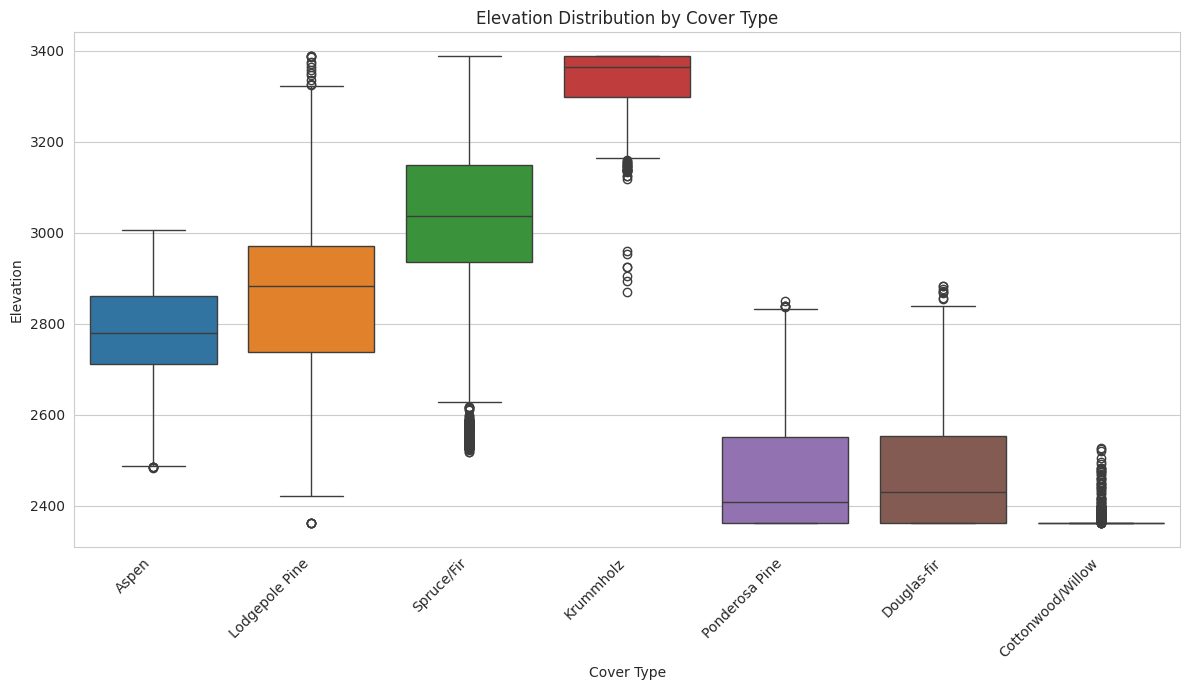

In [17]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=eda, x='Cover_Type', y='Elevation', hue='Cover_Type', palette='tab10', legend=False)
plt.title('Elevation Distribution by Cover Type')
plt.xlabel('Cover Type')
plt.ylabel('Elevation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

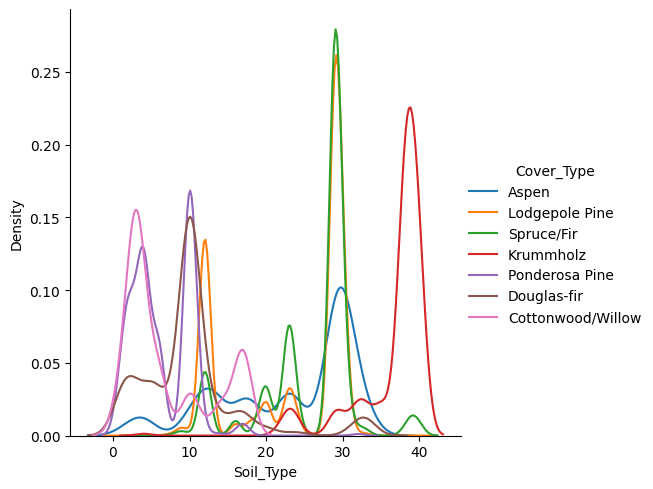

In [ ]:
sns.FacetGrid(data_feature, hue="Cover_Type", height=5).map(sns.kdeplot, "Soil_Type").add_legend();
plt.show();


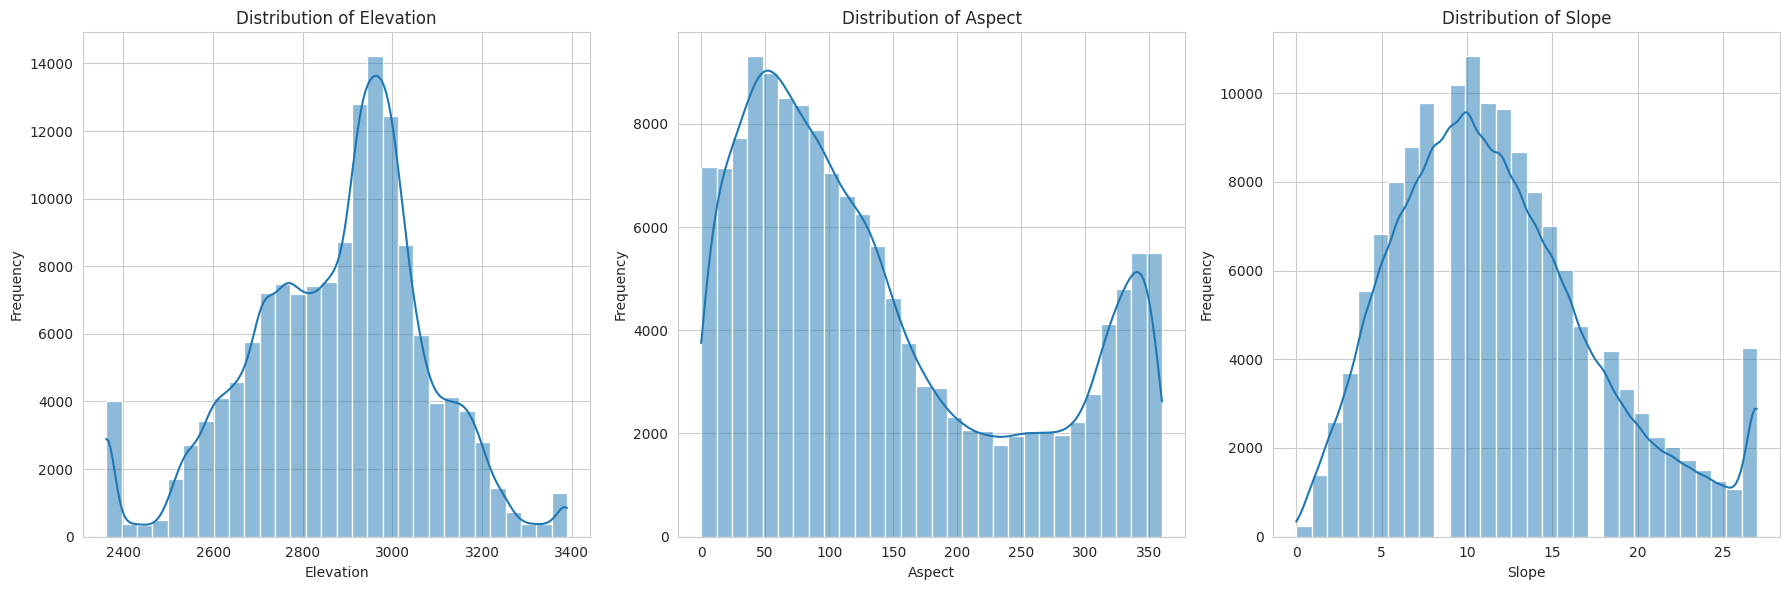

In [12]:
fig, axes = plt.subplots(1,3, figsize=(18,6)) # Increased figsize for better readability

sns.histplot(eda["Elevation"], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Elevation')
axes[0].set_xlabel('Elevation')
axes[0].set_ylabel('Frequency')

sns.histplot(eda["Aspect"], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Aspect')
axes[1].set_xlabel('Aspect')
axes[1].set_ylabel('Frequency')

sns.histplot(eda["Slope"], bins=30, kde=True, ax=axes[2])
axes[2].set_title('Distribution of Slope')
axes[2].set_xlabel('Slope')
axes[2].set_ylabel('Frequency')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

### Correlation Heatmap of Numerical Features

This heatmap visualizes the Pearson correlation coefficient between all numerical features in the `data_feature` DataFrame. Values close to 1 indicate a strong positive correlation, values close to -1 indicate a strong negative correlation, and values close to 0 indicate a weak or no linear correlation.

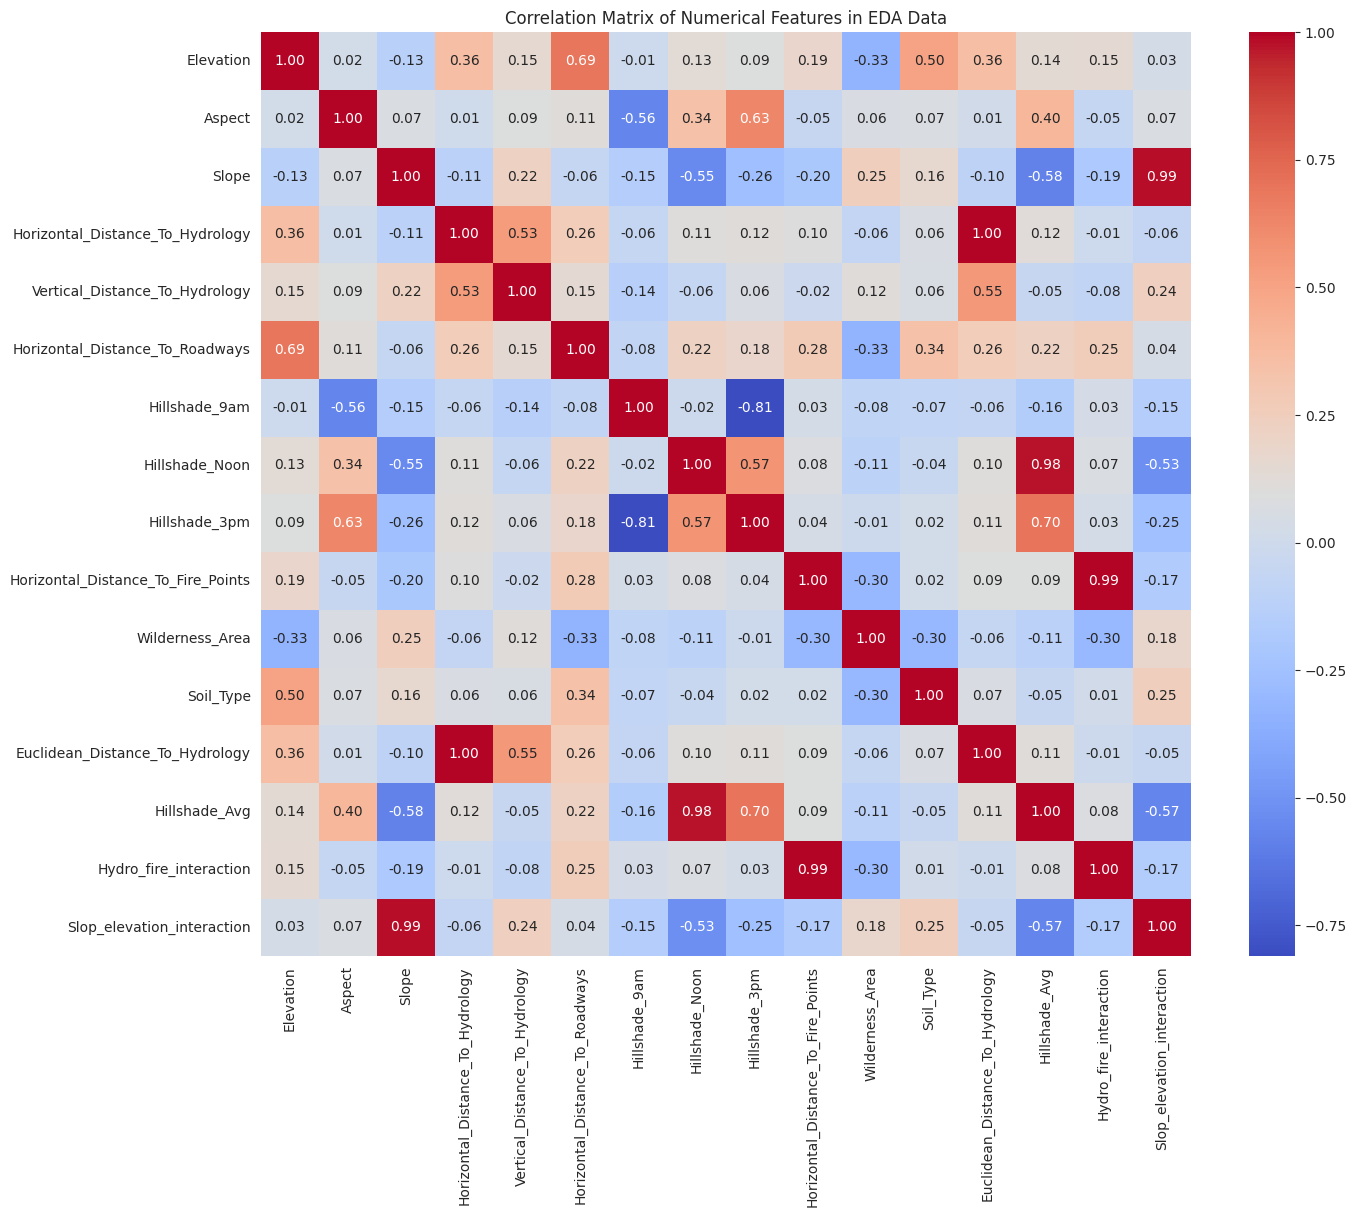

In [13]:
numerical_data_feature = eda.select_dtypes(include=np.number)

plt.figure(figsize=(15, 12))
sns.heatmap(numerical_data_feature.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features in EDA Data')
plt.show()

### Scatter Plots for Key Feature Relationships

Let's visualize the relationship between some highly important numerical features, colored by `Cover_Type`, to observe any distinct patterns or separations among the different forest cover types.

This scatter plot helps us understand how 'Elevation' and 'Horizontal_Distance_To_Roadways' jointly influence the distribution of different 'Cover_Type's. We can look for clusters or clear boundaries that define each forest type.

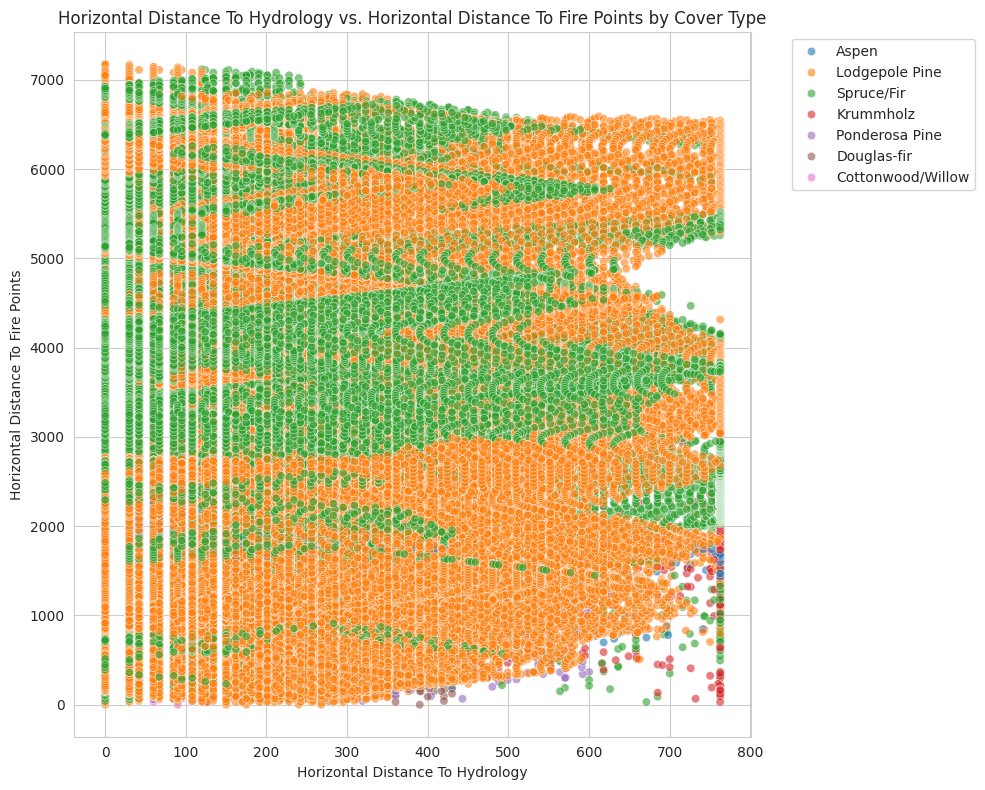

In [15]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=eda, x='Horizontal_Distance_To_Hydrology', y='Horizontal_Distance_To_Fire_Points', hue='Cover_Type', palette='tab10', alpha=0.6)
plt.title('Horizontal Distance To Hydrology vs. Horizontal Distance To Fire Points by Cover Type')
plt.xlabel('Horizontal Distance To Hydrology')
plt.ylabel('Horizontal Distance To Fire Points')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

This second scatter plot explores the relationship between proximity to water sources and fire ignition points, and how these factors differentiate the 'Cover_Type's. It can reveal environmental niches for specific forest types.

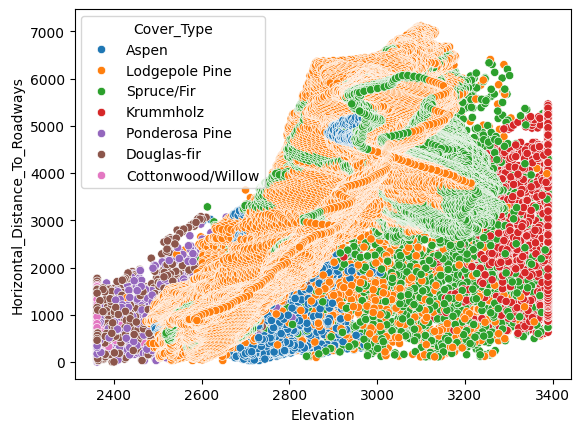

In [ ]:
sns.scatterplot(data=data_feature, hue="Cover_Type", x="Elevation", y="Horizontal_Distance_To_Roadways")
plt.show()

### Further Exploratory Data Analysis

Let's visualize the relationship between the newly engineered features and the `Cover_Type`. We will also explore the distributions of categorical features like `Wilderness_Area` and `Aspect_Category` against the target variable.

#### 1. Engineered Features vs. Cover Type (Box Plots)

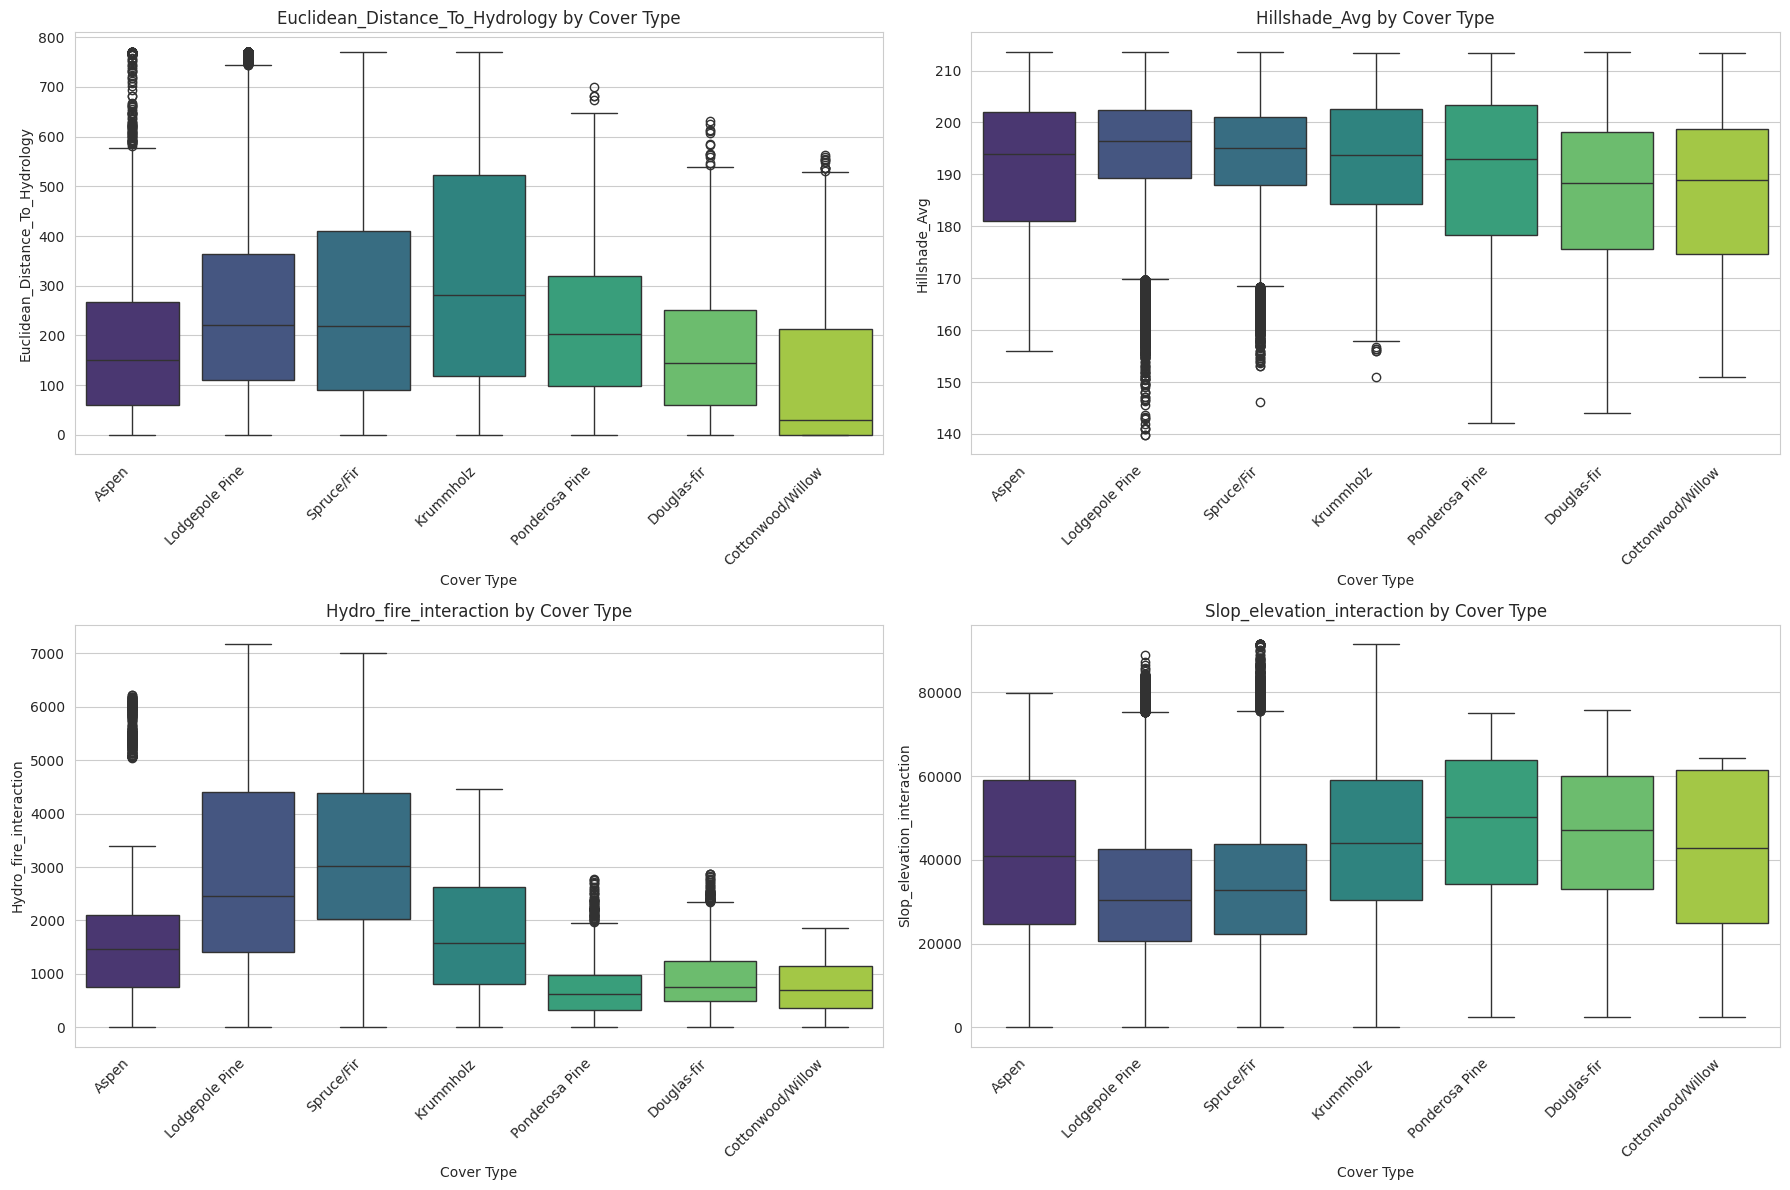

In [9]:
engineered_features = [
    'Euclidean_Distance_To_Hydrology',
    'Hillshade_Avg',
    'Hydro_fire_interaction',
    'Slop_elevation_interaction'
]

plt.figure(figsize=(18, 12))
for i, col in enumerate(engineered_features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=eda, x='Cover_Type', y=col, hue='Cover_Type', palette='viridis', legend=False)
    plt.title(f'{col} by Cover Type')
    plt.xlabel('Cover Type')
    plt.ylabel(col)
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 2. Categorical Features vs. Cover Type (Count Plots)

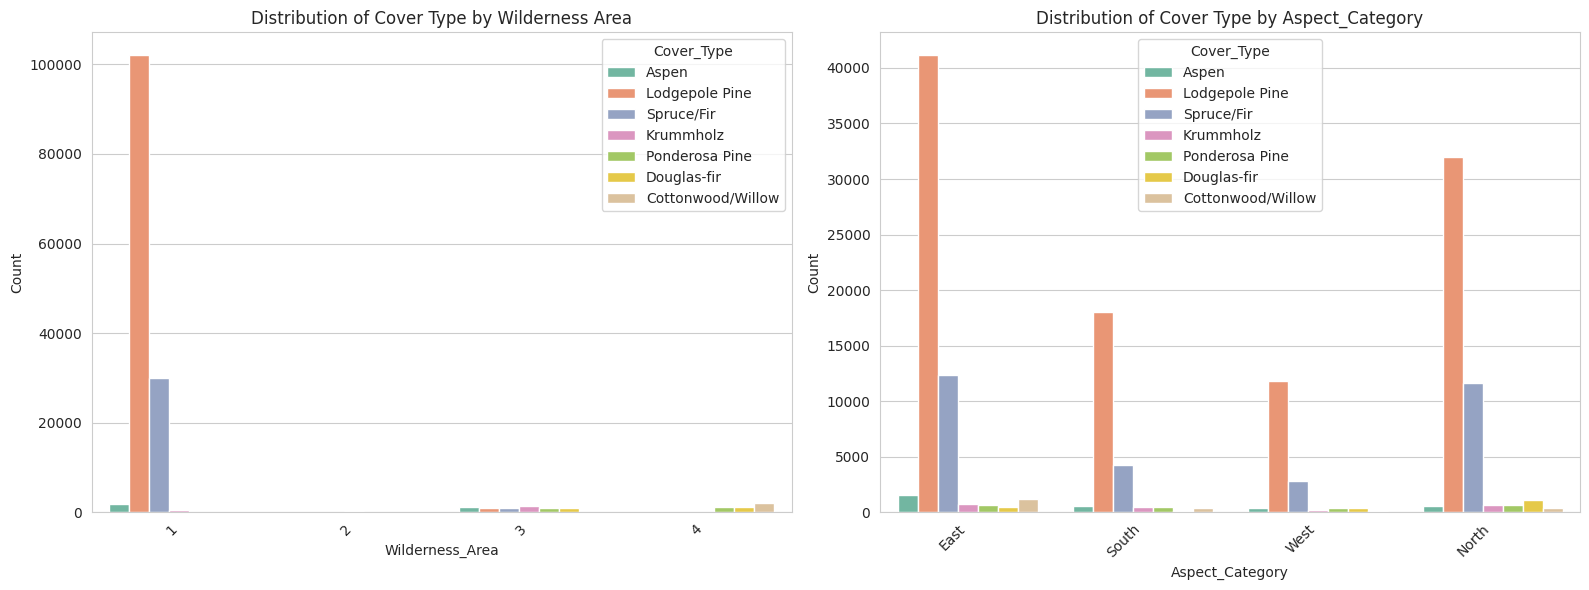

In [8]:
categorical_features = ['Wilderness_Area', 'Aspect_Category']

plt.figure(figsize=(16, 6))
for i, col in enumerate(categorical_features):
    plt.subplot(1, 2, i + 1)
    sns.countplot(data=eda, x=col, hue='Cover_Type', palette='Set2')
    plt.title(f'Distribution of Cover Type by {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    if col == 'Wilderness_Area':
        # Assuming Wilderness_Area is encoded as numbers, map to more descriptive labels if available
        # For now, just setting title
        plt.title('Distribution of Cover Type by Wilderness Area')
    else:
        plt.title(f'Distribution of Cover Type by {col}')
plt.tight_layout()
plt.show()

#### 3. Line Plots for Elevation and Horizontal Distance To Hydrology vs. Cover Type

These plots visualize the average 'Elevation' and 'Horizontal_Distance_To_Hydrology' for each `Cover_Type`. This can highlight if certain forest types are found at particular elevations or distances from water sources.

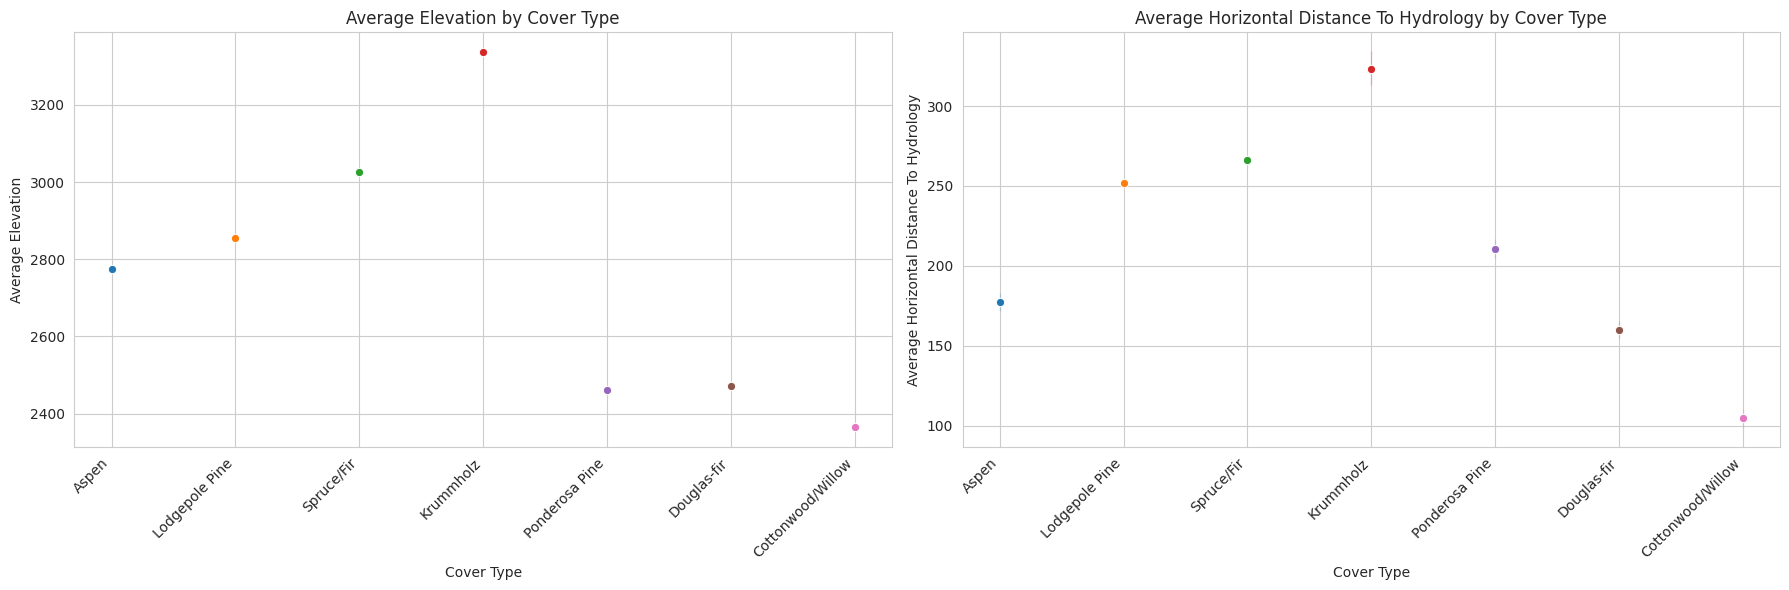

In [19]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
sns.lineplot(data=eda, x='Cover_Type', y='Elevation', marker='o', hue='Cover_Type', legend=False)
plt.title('Average Elevation by Cover Type')
plt.xlabel('Cover Type')
plt.ylabel('Average Elevation')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
sns.lineplot(data=eda, x='Cover_Type', y='Horizontal_Distance_To_Hydrology', marker='o', hue='Cover_Type', legend=False)
plt.title('Average Horizontal Distance To Hydrology by Cover Type')
plt.xlabel('Cover Type')
plt.ylabel('Average Horizontal Distance To Hydrology')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()